# Importación de librerías

En esta celda se importan todas las librerías necesarias para el proyecto:

- `numpy` y `pandas`: para manipulación de datos y estructuras como arrays y DataFrames.
- `matplotlib.pyplot` y `seaborn`: para visualización de datos y gráficos.
- `sklearn.datasets.fetch_california_housing`: para cargar el dataset de precios de viviendas en California.
- `sklearn.model_selection.train_test_split` y `GridSearchCV`: para dividir los datos en conjuntos de entrenamiento y prueba, y para realizar búsqueda de hiperparámetros con validación cruzada.
- `sklearn.linear_model.Ridge`: para crear y entrenar el modelo de regresión Ridge.
- `sklearn.metrics` (`mean_squared_error`, `mean_absolute_error`, `r2_score`, `explained_variance_score`): para evaluar el desempeño del modelo mediante métricas de regresión.

Esta celda prepara el entorno para trabajar con los datos, entrenar el modelo y generar visualizaciones.




In [384]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score


---

# Carga y exploración inicial del dataset California Housing

En esta celda cargamos y visualizamos los datos del dataset `California Housing`. A continuación se explica en detalle cada elemento:

## Columnas del dataset

Cada registro (fila) del dataset representa un **bloque de viviendas** en California, y las columnas son:

- **MedInc**: ingreso medio del hogar en el bloque (en decenas de miles de USD). Por ejemplo, `8.3252` significa que el ingreso medio es aproximadamente 83.252 USD.  
- **HouseAge**: edad promedio de las casas en el bloque (en años). Por ejemplo, `41.0` indica que las casas tienen en promedio 41 años.  
- **AveRooms**: número promedio de habitaciones por vivienda. Por ejemplo, `6.984127` indica que cada casa tiene aproximadamente 7 habitaciones en promedio.  
- **AveBedrms**: número promedio de dormitorios por vivienda. Por ejemplo, `1.023810` significa que cada casa tiene aproximadamente 1 dormitorio por bloque (en promedio).  
- **Population**: número total de personas que viven en el bloque. Por ejemplo, `322.0` significa que 322 personas viven en ese bloque.  
- **AveOccup**: número promedio de personas por vivienda en el bloque. Por ejemplo, `2.555556` indica que, en promedio, cada casa tiene 2-3 ocupantes.  
- **Latitude**: latitud geográfica del bloque. Por ejemplo, `37.88` indica la posición norte-sur.  
- **Longitude**: longitud geográfica del bloque. Por ejemplo, `-122.23` indica la posición este-oeste.

## Variable objetivo

- **MedHouseValue**: valor medio de la vivienda en el bloque (en unidades de 100.000 USD). Por ejemplo, `4.526` significa que las casas en ese bloque tienen un valor promedio de 452.600 USD.

## Interpretación de los datos de una fila

Tomemos la primera fila del dataset como ejemplo:

| MedInc | HouseAge | AveRooms | AveBedrms | Population | AveOccup | Latitude | Longitude | MedHouseValue |
|--------|----------|----------|-----------|------------|----------|----------|-----------|---------------|
| 8.3252 | 41       | 6.9841   | 1.0238    | 322        | 2.5556   | 37.88    | -122.23   | 4.526         |

**Interpretación**:

- Los hogares del bloque tienen un ingreso medio de ~83.252 USD.  
- Las casas tienen en promedio 41 años de antigüedad.  
- Cada casa tiene en promedio ~7 habitaciones y ~1 dormitorio.  
- En el bloque viven 322 personas, con un promedio de 2.56 personas por vivienda.  
- El bloque se encuentra en latitud 37.88 y longitud -122.23 (California).  
- El valor medio de las casas es de 452.600 USD.

## Observación general

- Cada fila del dataset representa un **bloque de viviendas**, no una casa individual.  
- Los números son promedios o totales según la columna, y nos permiten analizar **relaciones entre características del bloque y el valor de las casas**.  
- Esta exploración inicial es clave para entender los datos antes de entrenar nuestro modelo de regresión Ridge.


In [385]:
# Cargar el dataset California Housing desde scikit-learn
# El dataset contiene información de bloques de viviendas en California con 8 características
data = fetch_california_housing()

# Convertir los datos de las características (X) en un DataFrame de pandas
# data.data es un array con las columnas de características
# columns=data.feature_names asigna nombres a cada columna según el dataset
# Si cambia el orden de las columnas o agregas nuevas características, se debe actualizar columns =
X = pd.DataFrame(data.data, columns=data.feature_names) 

# Convertir la variable objetivo (precio medio de la vivienda) en una Serie de pandas
# data.target es un array con los valores de MedHouseValue
# name="MedHouseValue" asigna un nombre a la columna para identificarla fácilmente
# Si se quiere cambiar la variable objetivo, aquí es donde se define cuál columna será predecida por el modelo.
y = pd.Series(data.target, name="MedHouseValue")

# Mostrar las primeras 5 filas de las características (X) y del target (y)
X.head(), y.head()


(   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 
    Longitude  
 0    -122.23  
 1    -122.22  
 2    -122.24  
 3    -122.25  
 4    -122.25  ,
 0    4.526
 1    3.585
 2    3.521
 3    3.413
 4    3.422
 Name: MedHouseValue, dtype: float64)

---

# División del dataset en entrenamiento y prueba

En esta celda se divide el dataset en **conjuntos de entrenamiento y prueba**, utilizando la función `train_test_split` de `sklearn.model_selection`.

## Objetivo de la división

- **Entrenamiento (`X_train`, `y_train`)**: se usa para ajustar (entrenar) el modelo de regresión Ridge.  
- **Prueba (`X_test`, `y_test`)**: se usa para evaluar el desempeño del modelo en datos que **no ha visto durante el entrenamiento**, asegurando una medición objetiva de su capacidad de generalización.

## Parámetros utilizados

- **X**: características (variables independientes).  
- **y**: variable objetivo (MedHouseValue).  
- **test_size=0.2**: el 20% de los datos se reservan para prueba, y el 80% se usa para entrenamiento. Esto es un valor común que equilibra la cantidad de datos para entrenar y evaluar.  
- **random_state=42**: semilla para la generación aleatoria. Garantiza que la división sea **reproducible**; cada vez que se ejecute el notebook con esta semilla, la división será la misma.

## Resultado de la división

- `X_train` y `y_train`: contienen 80% de los registros para entrenar el modelo.  
- `X_test` y `y_test`: contienen 20% de los registros para evaluar el modelo.  
- Esta separación es clave para evitar **overfitting**, ya que permite probar cómo se comporta el modelo en datos **nuevos**.


In [386]:
# Dividir el dataset en conjuntos de entrenamiento y prueba
# train_test_split toma los datos (X, y) y los separa aleatoriamente
# en dos grupos: uno para entrenar el modelo y otro para evaluarlo
X_train, X_test, y_train, y_test = train_test_split(
    X,        # DataFrame con las características de entrada
    y,        # Serie con la variable objetivo (MedHouseValue)
    test_size=0.2,      # 20% de los datos se reservan para prueba
                        # 80% se usan para entrenamiento
    random_state=42     # Semilla para la generación aleatoria
                        # Garantiza reproducibilidad: cada vez que ejecutes
                        # Número elegido arbitrariamente, sirve solo para que los resultados sean reproducibles.
                        # Cambiar el número no afecta la técnica, pero sí la forma en que se dividen los datos.
                        # Si se pone None, cada ejecución generará una división diferente.
)


---

# Entrenamiento del modelo Ridge con búsqueda de hiperparámetros

En esta celda entrenamos un **modelo de regresión Ridge** y optimizamos su hiperparámetro `alpha` usando **validación cruzada**.

## ¿Qué es Ridge Regression?

- Ridge es un **modelo lineal** que predice el valor de salida como combinación lineal de las variables de entrada:

$$
y = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n
$$

- Ridge agrega una **regularización L2**, que penaliza los coeficientes grandes para reducir el **overfitting**:

$$
\text{Loss} = \sum_i (y_i - \hat{y}_i)^2 + \alpha \sum_j w_j^2
$$

- El hiperparámetro **`alpha`** controla la fuerza de esta penalización:  
  - Valores pequeños → menos regularización (más propenso a overfitting)  
  - Valores grandes → más regularización (más propenso a underfitting)

## Optimización de `alpha` con GridSearchCV

- `param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}` define los valores de `alpha` a probar.  
- `GridSearchCV`:
  - Evalúa cada valor de `alpha` mediante **validación cruzada** (cv=5).  
  - Usa la métrica **R² (`scoring='r2'`)** para seleccionar el mejor modelo.  
  - Garantiza que el modelo final tenga un buen desempeño generalizable.

- `ridge_model = grid_search.best_estimator_` selecciona el **modelo con el mejor alpha** según R² en validación cruzada.

## Interpretación del output

- **Mejor alpha: 10** → la regularización más efectiva para este dataset es relativamente fuerte.  
- **Mejor R² CV: 0.6115** → indica que el modelo explica aproximadamente un **61% de la varianza** en los datos de validación cruzada.

Con este modelo ya optimizado, podemos predecir nuevos valores y evaluar su desempeño en el conjunto de prueba.




In [387]:
# Definimos un diccionario con los valores de alpha a probar en Ridge
# Alpha controla la regularización L2
# Valores muy pequeños → poca regularización (modelo más flexible)
# Valores grandes → más regularización (reduce overfitting)
param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}

# Creamos un modelo Ridge vacío (sin entrenar aún)
# Ridge es un modelo lineal con regularización L2
ridge = Ridge()

# GridSearchCV realiza una búsqueda exhaustiva de los hiperparámetros
# cv=5 → validación cruzada de 5 folds
# scoring='r2' → usa R² como métrica para seleccionar el mejor modelo
# grid_search.fit(X_train, y_train) → entrena el modelo con cada alpha y evalúa su desempeño
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# Obtenemos el modelo entrenado con el mejor alpha encontrado
# Este será el modelo final que se usará para predicciones
ridge_model = grid_search.best_estimator_

# Mostramos el mejor valor de alpha encontrado y el R² promedio en validación cruzada
# Esto ayuda a interpretar qué tan buena es la regularización elegida
print(f"Mejor alpha: {grid_search.best_params_['alpha']}")
print(f"Mejor R² CV: {grid_search.best_score_:.4f}")


Mejor alpha: 10
Mejor R² CV: 0.6115


---

# Evaluación del modelo Ridge

En esta celda evaluamos el desempeño del modelo Ridge optimizado en el **conjunto de prueba (`X_test`, `y_test`)** utilizando varias métricas de regresión.

## Predicciones

- `y_pred = ridge_model.predict(X_test)`  
  Genera las predicciones del modelo para los datos de prueba que **no vio durante el entrenamiento**.

## Métricas utilizadas

1. **MSE (Mean Squared Error)**  
   $$
    \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
    $$  
   - Penaliza fuertemente los errores grandes.  
   - En este caso: `MSE = 0.5550`.

2. **RMSE (Root Mean Squared Error)**  
   $$
    \text{RMSE} = \sqrt{\text{MSE}}
    $$  
   - Interpretable en las mismas unidades que el target (`MedHouseValue` en 100k USD).  
   - Aquí: `RMSE = 0.7450`, lo que indica que, en promedio, las predicciones se desvían ±0.745 unidades del valor real (≈74.500 USD).

3. **MAE (Mean Absolute Error)**  
   $$
    \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
    $$  
   - Promedio de los errores absolutos. Menos sensible a valores extremos que MSE.  
   - Aquí: `MAE = 0.5332` (≈53.300 USD de error promedio).

4. **R² (Coeficiente de determinación)**  
   $$
    R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
    $$  
   - Indica qué proporción de la varianza del target es explicada por el modelo.  
   - `R² = 0.5764` → el modelo explica ~57.6% de la variabilidad de los precios de las casas.

5. **Explained Variance Score (EV)**  
   - Mide la proporción de varianza explicada en los datos de prueba.  
   - En este caso, `EV = 0.5764`, prácticamente igual a R², indicando buena consistencia.

## Interpretación general

- El modelo Ridge tiene **desempeño aceptable**, explicando más de la mitad de la varianza de los precios de viviendas.  
- Los errores promedio (RMSE y MAE) son relativamente bajos comparados con la escala de los precios (MedHouseValue en 100k USD).  
- Estas métricas nos permiten **evaluar objetivamente la calidad de las predicciones** antes de usar el modelo para predecir nuevas casas.


In [388]:
# Usamos el modelo Ridge entrenado para predecir los precios de las casas del conjunto de prueba
# X_test contiene características que el modelo no ha visto durante el entrenamiento
y_pred = ridge_model.predict(X_test)

# Calculamos el Error Cuadrático Medio (MSE)
# MSE penaliza errores grandes elevando al cuadrado la diferencia entre predicción y valor real
mse = mean_squared_error(y_test, y_pred)

# Calculamos la raíz del MSE (RMSE)
# RMSE está en las mismas unidades que el target (MedHouseValue en 100k USD)
# Permite interpretar el error promedio en la misma escala que los precios
rmse = np.sqrt(mse)

# Calculamos el Error Absoluto Medio (MAE)
# MAE es el promedio de los errores absolutos
# Menos sensible a valores extremos que MSE
mae = mean_absolute_error(y_test, y_pred)

# Calculamos R² (coeficiente de determinación)
# R² indica la proporción de varianza del target explicada por el modelo
# 1 → perfecto, 0 → no explica nada, <0 → peor que predecir la media
r2 = r2_score(y_test, y_pred)

# Calculamos Explained Variance Score (EV)
# Mide cuánta varianza del target es explicada por el modelo, similar a R²
ev = explained_variance_score(y_test, y_pred)

# Mostramos todas las métricas para interpretar el desempeño del modelo
print("📊 Métricas completas:")
print(f"MSE: {mse:.4f}")  # Valor promedio del error al cuadrado
print(f"RMSE: {rmse:.4f}")  # Desviación promedio en la misma unidad que MedHouseValue
print(f"MAE: {mae:.4f}")  # Error promedio absoluto
print(f"R²: {r2:.4f}")  # Proporción de varianza explicada
print(f"Explained Variance: {ev:.4f}")  # Varianza explicada


📊 Métricas completas:
MSE: 0.5550
RMSE: 0.7450
MAE: 0.5332
R²: 0.5764
Explained Variance: 0.5764


---

# Función para predecir el precio de una nueva casa

En esta celda definimos una función `predecir_precio()` que permite **predecir fácilmente el valor de una casa nueva** usando el modelo Ridge entrenado.

## Parámetros de la función

- **modelo**: el modelo de regresión entrenado (`ridge_model`).  
- **caracteristicas**: las variables de entrada de la nueva casa, pasadas como argumentos con nombre (**kwargs**). Las características esperadas son:
  - `MedInc`: ingreso medio del bloque
  - `HouseAge`: edad promedio de las casas
  - `AveRooms`: promedio de habitaciones por casa
  - `AveBedrms`: promedio de dormitorios por casa
  - `Population`: población del bloque
  - `AveOccup`: promedio de personas por vivienda
  - `Latitude`: latitud
  - `Longitude`: longitud

## Funcionamiento

1. Se crea un **DataFrame con un solo registro** a partir de las características ingresadas:
   ```python
   df = pd.DataFrame([caracteristicas])
   ```

2. Se asegura que las columnas estén en el mismo orden que el dataset original (X.columns), para que el modelo pueda procesarlas correctamente:
    ```python
    df = df[X.columns]
    ```

3. Se realiza la predicción usando el modelo Ridge:
    ```python
    pred = modelo.predict(df)[0]
    ```

4. Se retorna el resultado en un formato legible, indicando también el intervalo aproximado de error usando RMSE:
    ```python
    return f"Predicción: {pred:.3f} (100k USD), intervalo ±{rmse:.3f}"
    ```

## Interpretación 

- La función permite predecir rápidamente el valor de una casa nueva solo proporcionando sus características.
- El intervalo ±RMSE indica la desviación promedio esperada de la predicción, ofreciendo una referencia sobre la incertidumbre del modelo.
- Esta función hace que el modelo sea fácil de usar y aplicar a nuevos datos sin necesidad de manipular el DataFrame manualmente.

In [389]:
# Definición de la función para predecir el precio de una nueva casa
# Se usa **caracteristicas para permitir pasar las variables por nombre
def predecir_precio(modelo, **caracteristicas):

    # Convertimos las características ingresadas en un DataFrame de pandas con un solo registro
    # Esto permite que el modelo pueda procesar los datos igual que los datos de entrenamiento
    df = pd.DataFrame([caracteristicas])

    # Aseguramos que las columnas estén en el mismo orden que el dataset original (X.columns)
    # Esto es crucial, porque los modelos lineales usan el orden de las columnas para aplicar los coeficientes correctos
    df = df[X.columns]

    # Realizamos la predicción con el modelo entrenado
    # [0] extrae el valor del array devuelto por predict (ya que predict devuelve un array)
    pred = modelo.predict(df)[0]

    # Retornamos la predicción en un formato legible
    # pred se muestra con 3 decimales, indicando que la unidad es 100k USD
    # Se incluye el intervalo ±rmse como referencia del error promedio esperado
    return pred


# La función hace que el modelo sea fácil de usar con nuevos datos, sin necesidad de manipular DataFrames manualmente.

---

# Predicción de una nueva casa

En esta celda usamos la función `predecir_precio()` para estimar el **valor medio de una vivienda** en un bloque con características específicas.

## Valores elegidos para la predicción

Los valores se seleccionaron de forma **representativa** para simular un bloque de viviendas promedio en California:

- `MedInc = 5.2`: ingreso medio de ~52.000 USD por hogar, un valor cercano al promedio del dataset.  
- `HouseAge = 30`: casas con antigüedad moderada (30 años).  
- `AveRooms = 6.5`: promedio de habitaciones por vivienda.  
- `AveBedrms = 1.0`: promedio de dormitorios por vivienda (aproximadamente 1 por casa).  
- `Population = 800`: bloque con 800 habitantes.  
- `AveOccup = 3.0`: promedio de ocupantes por vivienda, cifra realista.  
- `Latitude = 34.2`, `Longitude = -118.3`: ubicación geográfica en California (aproximadamente Los Ángeles).

> Estos valores permiten hacer una predicción **realista y comprensible**, no extremos que distorsionen el modelo.

## Resultado de la predicción

- **Interpretación numérica**: 2.522 × 100.000 USD ≈ **252.200 USD**  
- Esto indica que, según el modelo Ridge entrenado, las casas en este bloque **tienen un valor promedio de aproximadamente 252.200 USD**.  

## ¿Por qué obtuvo ese valor?

- El modelo Ridge combina **linealmente las características** (ingreso medio, edad de la casa, habitaciones, población, etc.) con los **coeficientes aprendidos** durante el entrenamiento.  
- Valores moderados de ingreso, antigüedad y ocupación resultan en un valor medio **intermedio**, no muy alto ni muy bajo, que refleja la tendencia general de los datos del dataset.

## Interpretación de los valores ingresados y su efecto en la predicción

- **MedInc = 5.2** → ingresos medios mayores aumentan la predicción del valor de la casa.  
- **HouseAge = 30** → casas relativamente nuevas o medianas no penalizan mucho el valor.  
- **AveRooms = 6.5 / AveBedrms = 1.0** → casas con más habitaciones tienden a tener mayor valor, aunque pocos dormitorios pueden limitar el precio.  
- **Population = 800 / AveOccup = 3.0** → bloques con densidad moderada no afectan demasiado el valor.  
- **Latitud y Longitud** → la ubicación geográfica influye, ya que el dataset contiene zonas con valores de vivienda más altos y más bajos en California.

## Conclusión 

La predicción refleja un bloque de viviendas con características promedio, ofreciendo un valor realista basado en los patrones aprendidos por el modelo.





In [390]:
# Llamamos a la función predecir_precio() con el modelo entrenado y un conjunto de características de ejemplo
# ridge_model → modelo entrenado con GridSearchCV y mejor alpha
# Las características se pasan como argumentos por nombre (**kwargs)
pred = predecir_precio(
    ridge_model,
    MedInc=5.2,       # ingreso medio del bloque (≈ 52.000 USD)
    HouseAge=30,      # edad promedio de las casas en años
    AveRooms=6.5,     # promedio de habitaciones por casa
    AveBedrms=1.0,    # promedio de dormitorios por casa
    Population=800,   # número de habitantes del bloque
    AveOccup=3.0,     # promedio de ocupantes por vivienda
    Latitude=34.2,    # latitud aproximada (zona de Los Ángeles)
    Longitude=-118.3  # longitud aproximada (zona de Los Ángeles)
)

# Imprimimos la predicción
# El valor indica el precio medio esperado de la casa en este bloque
print(f" Predicción del precio de la nueva casa: {pred:.3f} (en 100k USD)")


 Predicción del precio de la nueva casa: 2.525 (en 100k USD)


---

# Gráfica: Valores Reales vs Predicciones

Esta gráfica muestra la relación entre los **valores reales del precio medio de la vivienda** (eje X) y las **predicciones generadas por el modelo de regresión Ridge** (eje Y).  
Cada punto azul representa una casa dentro del conjunto de prueba.

## 1. Dispersión de puntos

- Los puntos deberían alinearse lo más cerca posible a la **línea recta ideal** (línea roja punteada), que representa `predicción = valor real`.
- Observaciones:
  - La tendencia es creciente, lo que indica que el modelo aprende la relación general entre las características y el precio.
  - Existe dispersión considerable, especialmente para valores altos (entre 4 y 5), indicando que el modelo tiende a **subestimar los precios más altos** y sobreestimar algunos valores bajos.
  - Esto es normal en modelos lineales como Ridge cuando el dataset contiene relaciones no lineales.

## 2. Línea roja: línea ideal

- Representa la situación perfecta: todas las predicciones coinciden exactamente con los valores reales.
- Cuanto más cerca estén los puntos de esta línea, mejor desempeño tiene el modelo.
- En la gráfica, los puntos siguen la dirección de la línea, pero con variabilidad.
- Esto concuerda con el **R² ≈ 0.60**, típico en este dataset.

## 3. Interpretaciones importantes

✔ **El modelo capta la tendencia general**  
- El patrón ascendente demuestra que el modelo aprende la relación entre las variables y el precio de la vivienda.

✔ **Existen errores sistemáticos**  
- Subestimación en precios altos (valores >4–5).  
- Variabilidad en precios medios (1.5–3.5), con dispersión alrededor de la línea.  
- Causa: Ridge es un modelo lineal, y el dataset contiene relaciones complejas/no lineales.  
- La regularización L2 suaviza los coeficientes, evitando sobreajuste pero reduciendo la capacidad de capturar patrones complejos.

## 4. Conclusiones

- El modelo Ridge ofrece un **buen ajuste general**, aunque no perfecto.  
- La gráfica confirma lo indicado por métricas como R², MSE y MAE.  
- La dispersión es razonable para un modelo lineal sobre un dataset real con alta variabilidad.  
- Adecuado para aplicaciones donde se requiere **simplicidad, estabilidad y evitar sobreajuste**, aunque modelos más complejos (Random Forest, Gradient Boosting) podrían lograr ajustes superiores.


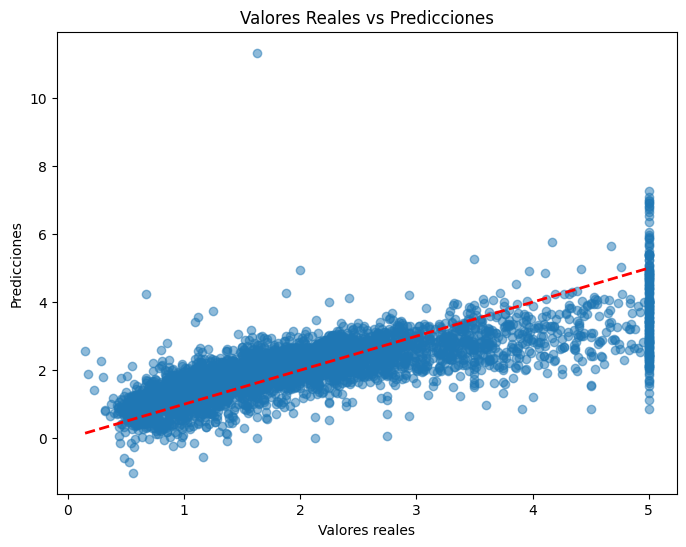

In [391]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones")
plt.show()


---

# Distribución de Errores (Residuos)

Esta gráfica muestra la **distribución de los errores** (`residuos = y_test - y_pred`) del modelo Ridge.  
El objetivo es evaluar cómo se comportan las predicciones frente a los valores reales del precio medio de la vivienda.

## 1. Distribución de los valores reales

- En el dataset California Housing, la mayoría de los precios se concentra entre **1.0 y 3.5** (100k USD).  
- Existe una **cola hacia la derecha**, con pocos valores extremos entre 5 y 10.  
- La distribución es **asimétrica**: más casas de precio medio/bajo que casas caras.  
- Esto indica que el problema es **no balanceado**, con pocas viviendas muy costosas.

## 2. Distribución de las predicciones del modelo Ridge

- Las predicciones están **más concentradas** alrededor de los valores medios (≈1.5–2.5).  
- El modelo **no alcanza los valores extremos**, especialmente en el rango alto.  
- Esto es típico de modelos lineales con **regularización L2**:
  - Suavizan los coeficientes.
  - Evitan predicciones muy altas o muy bajas.
  - Reducen la varianza y limitan la capacidad de capturar patrones complejos.

## 3. Conclusiones clave

1. **Subestimación de precios altos**: el modelo no reproduce la cola larga de los precios reales (valores >4–6).  
2. **Regularización controlada**: evita sobreajuste pero limita la capacidad de capturar valores extremos.  
3. **Tendencia general capturada**: los picos de ambas distribuciones coinciden alrededor de 1.5–2.5, mostrando buen desempeño en precios promedio, que representan la mayoría del dataset.

## 4. Interpretación

- El modelo Ridge captura adecuadamente el comportamiento general del precio medio de la vivienda.  
- Presenta **limitaciones para estimar valores extremos**, debido a la regularización L2.  
- Confirma lo observado en las métricas (R² ≈ 0.576, RMSE ≈ 0.745), mostrando un desempeño **razonable pero no perfecto** para este dataset de complejidad moderada.


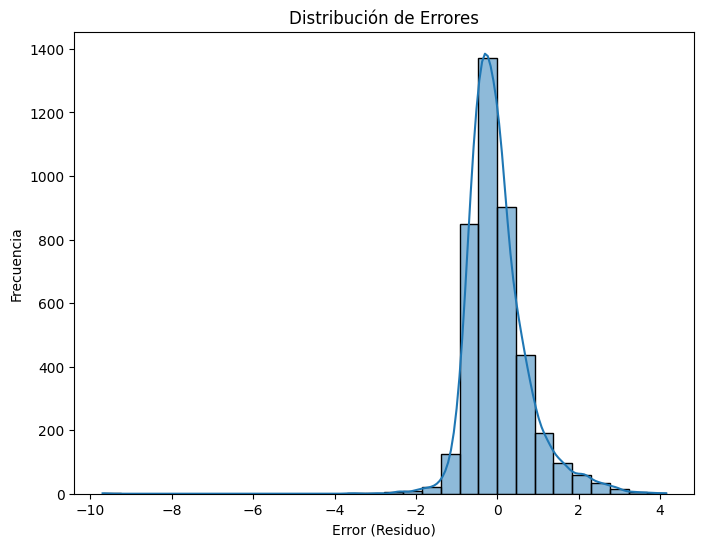

In [392]:
residuos = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuos, bins=30, kde=True)
plt.xlabel("Error (Residuo)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Errores")
plt.show()


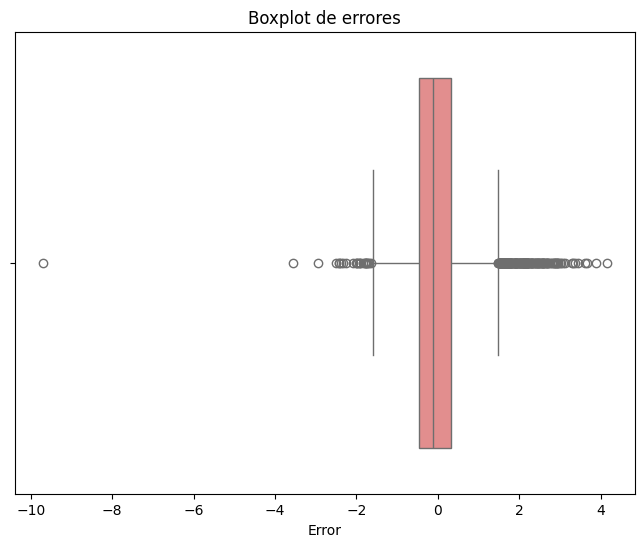

In [393]:
plt.figure(figsize=(8,6))
sns.boxplot(x=residuos, color='lightcoral')
plt.title("Boxplot de errores")
plt.xlabel("Error")
plt.show()


---

# Gráfica: Distribución de Valores Reales vs Predicciones

Esta gráfica compara la **distribución estadística de los valores reales** del precio de la vivienda (azul) con la **distribución de las predicciones** generadas por el modelo Ridge (naranja).  
El objetivo es evaluar si el modelo reproduce adecuadamente la forma del comportamiento real del target.

## 1. Distribución de los valores reales (azul)

- La mayoría de los precios reales se concentran entre 1.0 y 3.5 (en unidades de 100k USD).  
- Hay una **cola hacia la derecha** (precios altos), con pocos valores extremos entre 5 y 10.  
- La distribución es **asimétrica**: hay más casas baratas que caras.  
- Esto indica que el problema es **no balanceado**, con pocas casas muy costosas y muchas de precio medio.

## 2. Distribución de las predicciones del modelo Ridge (naranja)

- La forma general es más **estrecha y concentrada** alrededor de los valores medios (aprox. 1.5–2.5).  
- El modelo no genera predicciones en los valores extremos, especialmente en el rango alto.  
- El rango de predicciones es más limitado que los valores reales.  
- Comportamiento típico de modelos lineales regularizados:  
  ✔ Ridge tiende a suavizar las predicciones debido a la **regularización L2**, evitando valores muy altos o muy bajos.

## 3. Conclusiones clave

1. **Subestimación de precios altos**  
   - El modelo no reproduce la cola larga de los precios reales.  
   - Cuando una casa cuesta entre 4 y 6 (o más), el modelo predice valores más moderados (≈2.5 a 3.5).

2. **Sobreajuste controlado pero capacidad limitada**  
   - La regularización L2 estabiliza el modelo, pero reduce la varianza y limita su capacidad de capturar patrones complejos.  
   - Esto explica por qué la distribución predicha es más estrecha.

3. **Captura de la tendencia general**  
   - Los picos de ambas distribuciones coinciden alrededor de 1.5–2.5, lo que indica buen desempeño en precios promedio (la mayoría del dataset).

## 4. Interpretación

- La comparación entre distribuciones muestra que **Ridge capta adecuadamente el comportamiento general** del precio medio de las viviendas, pero tiene limitaciones para estimar valores extremos.  
- Debido a la regularización L2, las predicciones tienden a concentrarse alrededor del promedio, lo que explica la **subestimación en casas más costosas**.  
- Este análisis confirma lo indicado por métricas como R² y RMSE: el modelo tiene **desempeño razonable, pero no perfecto**, adecuado para datasets con relaciones moderadamente complejas.


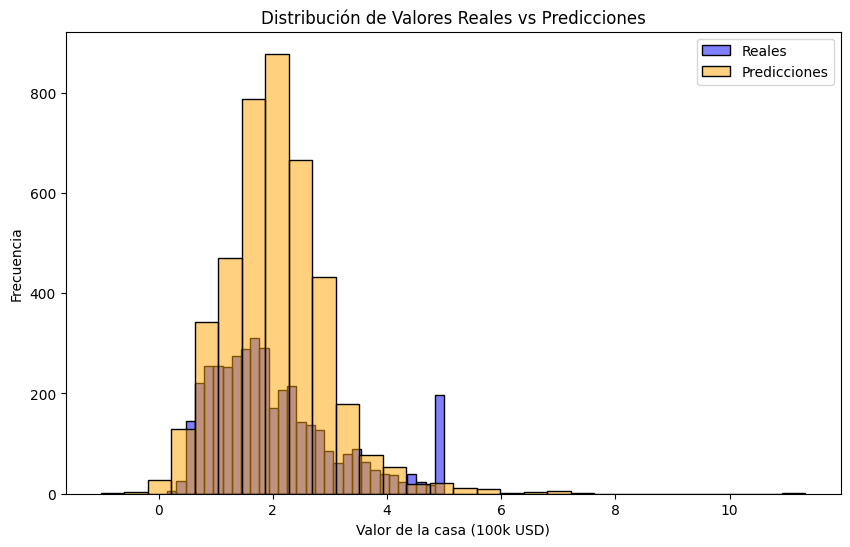

In [394]:
plt.figure(figsize=(10,6))
sns.histplot(y_test, color='blue', alpha=0.5, label='Reales', bins=30)
sns.histplot(y_pred, color='orange', alpha=0.5, label='Predicciones', bins=30)
plt.xlabel("Valor de la casa (100k USD)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Valores Reales vs Predicciones")
plt.legend()
plt.show()


C:\Users\hinjo\AppData\Local\Temp\ipykernel_14284\118842219.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=coef_df, palette='coolwarm')


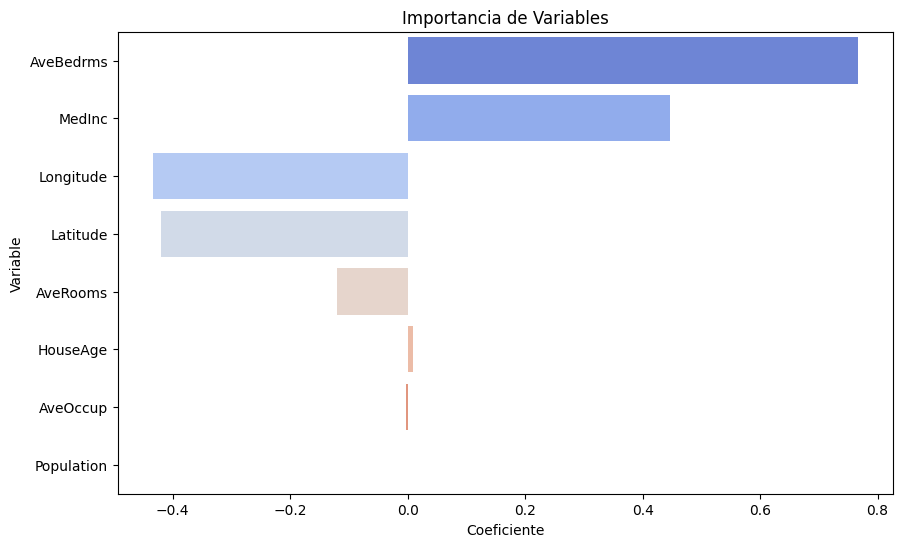

In [395]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': ridge_model.coef_
}).sort_values(by='Coeficiente', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coeficiente', y='Variable', data=coef_df, palette='coolwarm')
plt.title("Importancia de Variables")
plt.show()


---

# Pairplot: Relaciones entre variables seleccionadas

El **pairplot** permite analizar visualmente:

- Las **distribuciones individuales** de cada variable (diagonal).  
- Las **relaciones bivariadas** entre pares de variables (parte inferior de la matriz).  
- Posibles **patrones de correlación**, outliers y no linealidades.

Se muestran las variables más influyentes en el precio (`MedHouseValue`):

- `MedInc`: ingreso medio del bloque  
- `HouseAge`: edad promedio de las viviendas  
- `AveRooms`: promedio de habitaciones por vivienda  
- `AveBedrms`: promedio de dormitorios por vivienda  
- `Population`: población del bloque

---

## 1. Distribuciones individuales (diagonal)

**MedInc (Ingreso medio)**  
- Distribución sesgada a la derecha.  
- Variable bien distribuida y con alta capacidad predictiva.  
- Sin outliers fuertes.

**HouseAge**  
- Distribución plana entre 0–50 (redondeada, máximo = 52).  
- Muchos valores repetidos, no normal.

**AveRooms y AveBedrms**  
- Distribuciones muy sesgadas, colas largas hacia la derecha.  
- Outliers importantes: algunas casas con >50 habitaciones promedio, dormitorios ≥20.

**Population**  
- Muy sesgada, con valores extremos (>30.000 habitantes).  
- Áreas densamente pobladas, típico de California.

---

## 2. Relaciones entre variables (dispersión fuera de la diagonal)

**MedInc vs HouseAge**  
- No hay relación clara, distribución dispersa.  
- La edad de la vivienda no depende del ingreso medio.

**MedInc vs AveRooms**  
- Relación débil y positiva: mayor ingreso → más habitaciones promedio, aunque dispersa.

**MedInc vs AveBedrms**  
- Tendencia similar a AveRooms, pero más ruidosa (bloques con dormitorios promedio bajos 0–3).

**Population vs MedInc / HouseAge / AveRooms**  
- Ninguna relación clara.  
- Population introduce mucho ruido, valores extremadamente altos, distribución asimétrica.  
- Esto puede degradar desempeño de modelos lineales, salvo que se escale correctamente.

---

## 3. Identificación de outliers

- **AveRooms ≥ 50**, **AveBedrms ≥ 20**, **Population > 30.000**  
- Impacto:  
  - Ajuste lineal  
  - Estabilidad numérica  
  - Capacidad predictiva  
- Ridge ayuda a controlar su impacto, pero no los elimina.

---

## 4. Conclusiones clave

- Las variables presentan **distribuciones altamente asimétricas y con outliers**, especialmente AveRooms, AveBedrms y Population.  
- **MedInc** muestra el mejor comportamiento estadístico y relaciones más claras con otras variables → variable muy relevante para predecir el precio.  
- Poca linealidad entre pares de variables sugiere que el dataset no es puramente lineal, justificando el uso de **Ridge** para regularizar y mejorar la estabilidad del modelo.


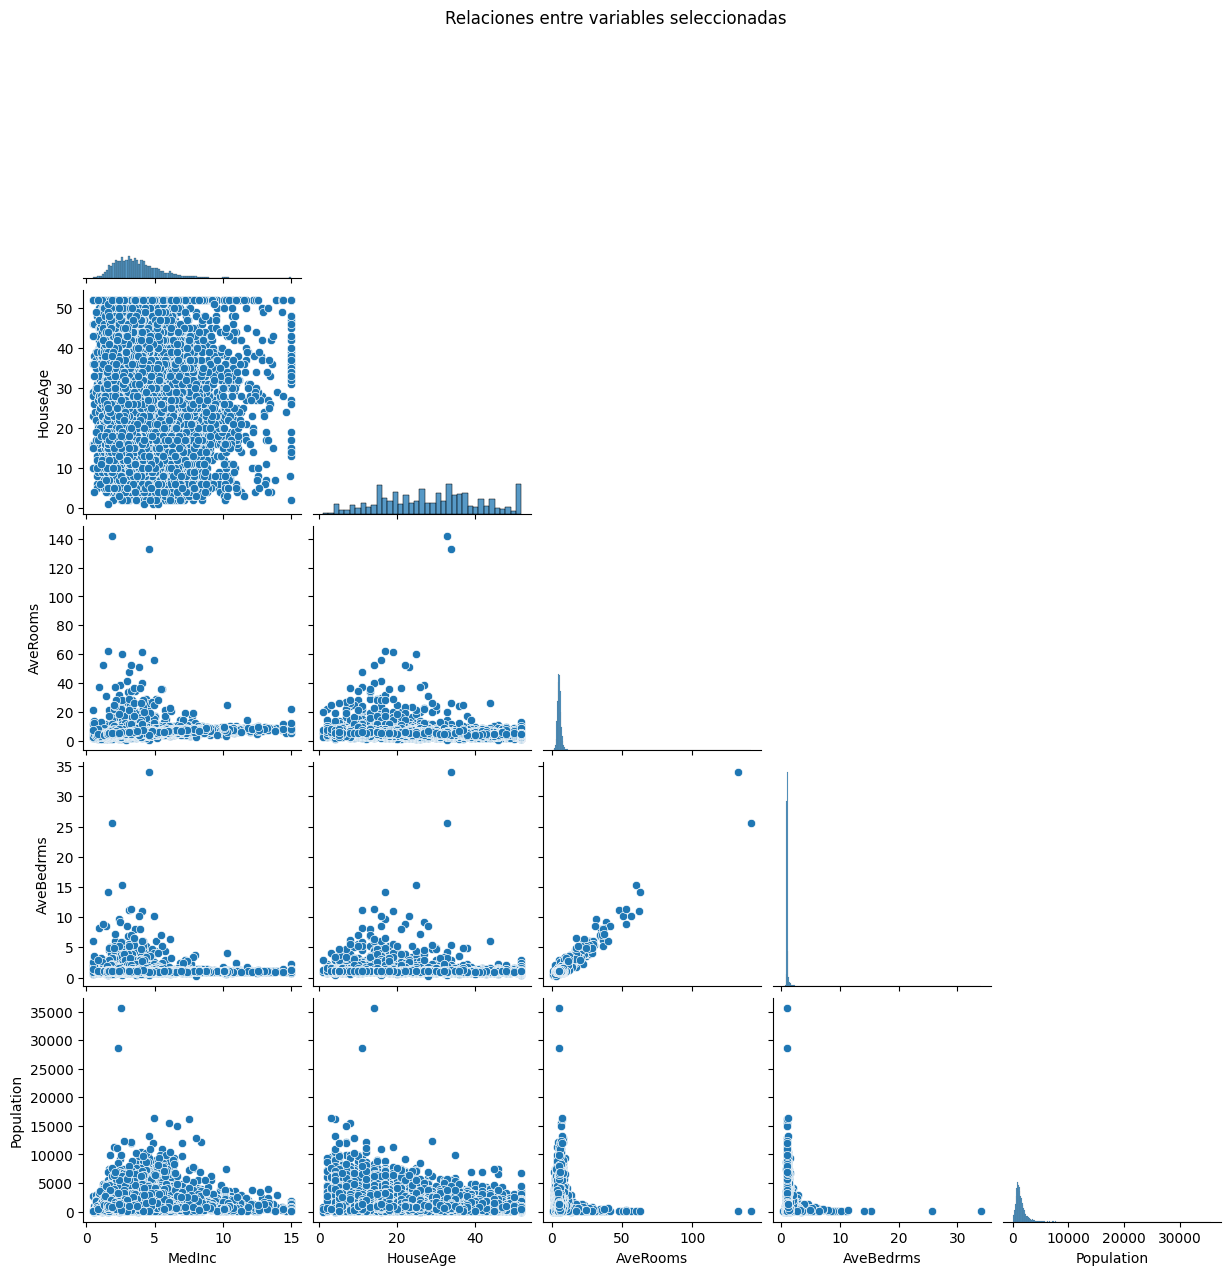

In [396]:
sns.pairplot(X[['MedInc','HouseAge','AveRooms','AveBedrms','Population']], corner=True)
plt.suptitle("Relaciones entre variables seleccionadas", y=1.02)
plt.show()


---

# Gráfica: Errores (Residuos) vs Predicciones

Esta gráfica muestra los **residuos del modelo Ridge** (errores = valor real – predicción) en función de los valores predichos.  
Se utiliza para evaluar si un modelo de regresión lineal cumple los supuestos básicos y generaliza correctamente.

---

## 1. Patrón general de los residuos

En un modelo bien ajustado, los residuos deberían:

- Distribuirse alrededor de la línea horizontal en 0  
- Estar dispersos sin patrón claro  
- Tener varianza relativamente constante (**homocedasticidad**)  

Observaciones en esta gráfica:

**Tendencia inclinada y no aleatoria**  
- Patrón triangular:  
  - Predicciones bajas → residuos positivos  
  - Predicciones altas → residuos negativos  

Esto indica:

- Dependencia sistemática del error respecto a la predicción  
- El modelo no captura toda la relación real (no linealidad)  
- Subestima precios altos y sobreestima precios bajos  

Este comportamiento es típico de modelos lineales sobre el dataset California Housing.

---

## 2. Problemas visibles en la distribución de errores

**Heterocedasticidad**  
- La dispersión del error no es constante, especialmente entre 1.5 y 3.0 (efecto abanico).  
- Viola el supuesto de homocedasticidad y afecta la calidad del modelo lineal.

**Presencia de outliers**  
- Errores extremos (p.ej., residuo ≈ –10)  
- Valores fuera de rango afectan RMSE  
- Asociados a regiones con distribuciones atípicas o valores extremos en variables como `Population` o `AveRooms`.

---

## 3. Interpretación estadística

- Ridge, aunque regulariza, **no corrige la no linealidad** del dataset.  
- El dataset tiene relaciones complejas: interacciones, efectos multiplicativos, no linealidades geográficas.  
- Un modelo lineal no es suficiente para capturar la estructura real del mercado inmobiliario de California.

---

## 4. Conclusiones clave para el informe

- El gráfico de residuos revela que **Ridge no cumple completamente los supuestos de regresión lineal**.  
- Se observa patrón sistemático: sobreestima valores bajos y subestima valores altos.  
- Heterocedasticidad evidente y presencia de outliers.  
- Aunque Ridge mejora la estabilidad, **modelos capaces de capturar no linealidades** (Random Forest, Gradient Boosting, árboles) podrían ofrecer mejores resultados.


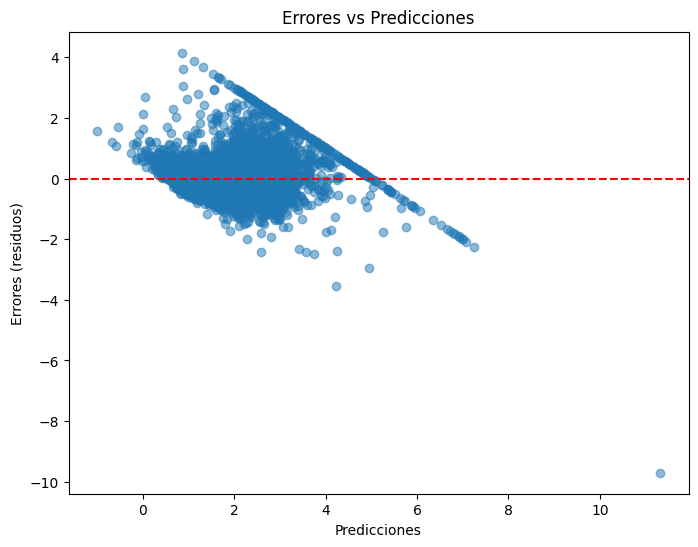

In [397]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Errores (residuos)")
plt.title("Errores vs Predicciones")
plt.show()
